# The Luminal compiler take-home, explained from zero

**Source of truth:** `luminal-challenge/.reference/`, a pinned copy of
`github.com/luminal-ai/interview`. Every rule quoted in this notebook is read
out of that code at run time rather than retyped, so if the reference ever
changed, the cells below would disagree with the prose and you would see it.

**How to run this.** Pick the kernel named **`causalbool`** — in the environment
picker it is the last entry, `.venv (Python 3.13.12) · venv/bin/python`. Then
run the cells in order, top to bottom. Nothing here writes to the repository,
and nothing touches the pinned reference.

**No compiler background is assumed.** Section 1 builds every term from
scratch — cycle, engine, bundle, latency, scratchpad, allocation — on a
four-operation program you can hold in your head. Everything afterwards is the
same ideas on a larger program.

---

## 0. Setup

Two directories go on the import path: `.reference/` for the frozen machine and
starter compiler, and the challenge root for our own helper modules.

In [1]:
import json
import math
import sys
from pathlib import Path

ROOT = Path("/Users/alberto/Documents/projects/CausalBool/luminal-challenge").resolve()
for entry in (str(ROOT / ".reference"), str(ROOT), str(ROOT / "notebooks")):
    if entry not in sys.path:
        sys.path.insert(0, entry)

import machine          # the frozen machine model and validator (do not modify)
import compiler         # the starter compiler we are asked to improve
import direct_contract  # our own derived-facts helper, built on top of machine
from common import issue_times   # the owner of "which cycle did each operation issue?"

# Every figure in this notebook is drawn by one module, shared with notebook 01,
# so a picture and a number can never come from two different definitions.
from viz import (narrate, show_timeline, show_lifetimes, show_inflight,
                 show_sharing_rule, show_memory_ordering, show_memory_chain)

print("python     :", sys.version.split()[0])
print("machine    :", Path(machine.__file__).relative_to(ROOT))
print("compiler   :", Path(compiler.__file__).relative_to(ROOT))
print("figures    :", Path(sys.modules["viz"].__file__).relative_to(ROOT))

python     : 3.13.12
machine    : .reference/machine.py
compiler   : .reference/compiler.py
figures    : notebooks/viz.py


---

# 1. Basic concepts, built from nothing

## 1.1 What a compiler backend is actually for

A program, as written, says **what** to compute: read these two numbers, add
them, write the answer. It says nothing about **when** each step happens or
**where** the intermediate numbers are kept. Real hardware needs both of those
answered before it can run anything, and answering them is the job of the part
of a compiler called the *backend*.

In this exercise the "what" is fixed and handed to you. You may not change a
single operation. You answer only the two remaining questions:

| Question | The name for answering it | Where the answer goes |
|---|---|---|
| **When** does each operation run? | **scheduling** | the `bundles` list |
| **Where** does each result live? | **(scratch) allocation** | the `scratch` map |

An analogy that maps exactly, and that I will keep using:

> A kitchen with a clock on the wall. The clock ticks. At each tick you may hand
> jobs to your specialist cooks — but only as many as each specialist can start
> at once. A job handed over at one tick is not finished at that tick; it takes a
> known number of ticks, and until then its result does not exist. Finished
> results are put on a **numbered shelf** with a fixed number of slots, and that
> shelf is the only place anything can be kept. A cook can only read ingredients
> that are already sitting on the shelf.
>
> **Scheduling** is deciding at which tick each job is handed over.
> **Allocation** is deciding which shelf slot each result is put on.

Let us make every word of that concrete.

## 1.2 The smallest possible program

Four operations: read a number from buffer `x`, read one from buffer `y`, add
them, write the sum to buffer `out`. Written in the challenge's own JSON.

In [2]:
tiny = {
    "name": "tiny",
    "buffers": {"x": 1, "y": 1, "out": 1},     # three memory buffers of one word each
    "operations": [
        {"id": 0, "op": "load",  "dest": "a", "buffer": "x", "offset": 0},
        {"id": 1, "op": "load",  "dest": "b", "buffer": "y", "offset": 0},
        {"id": 2, "op": "add",   "dest": "s", "args": ["a", "b"]},
        {"id": 3, "op": "store", "args": ["s"], "buffer": "out", "offset": 0},
    ],
    "cases": [{"x": [20], "y": [22], "out": [0]}],
}

machine.validate_program(tiny)          # raises if the program is malformed
tiny_facts = direct_contract.derive(tiny)

print("what it computes:", machine.run_reference(tiny, tiny["cases"][0]))

what it computes: {'x': [20], 'y': [22], 'out': [42]}


`run_reference` just interprets the operations directly: it is the answer the
grader will demand. `out` becomes 42.

Note the vocabulary the JSON is already using:

- **`dest`** is the *name of a value*, not a place. `"dest": "a"` means "call the
  number this operation produces `a`". Where `a` physically sits is your
  decision, not the program's.
- **`args`** refer to those names. Operation 2 needs the values named `a` and `b`.
- **`buffers`** are main memory, outside the machine's shelf. Only `load`,
  `vload`, `store` and `vstore` touch them.

## 1.3 What a cycle is

A **cycle** is one tick of the machine's clock. It is the unit of time, and it
is the only unit of time — nothing here is measured in seconds.

Each cycle, the machine does exactly one thing: it takes the bundle of work you
scheduled for that cycle and hands it to the engines. That is called **issuing**.

**Latency** is how many cycles pass between an operation being issued and its
result becoming usable. It is fixed per opcode and you can read it from the
machine:

In [3]:
for opcode in ("load", "add", "mul", "store", "vload", "vmul"):
    spec = machine.OP_SPECS[opcode]
    print(f"{opcode:6} runs on the {spec['engine']:7} engine, "
          f"latency {spec['latency']} cycle(s)")

load   runs on the load    engine, latency 3 cycle(s)
add    runs on the scalar  engine, latency 1 cycle(s)
mul    runs on the scalar  engine, latency 2 cycle(s)
store  runs on the store   engine, latency 1 cycle(s)
vload  runs on the load    engine, latency 4 cycle(s)
vmul   runs on the vector  engine, latency 3 cycle(s)


So a `load` issued at cycle 0 has its value ready at cycle **3**, not at cycle 0
and not at cycle 1. Cycles 1 and 2 are simply waiting. The result is *not*
available in the same cycle it was issued — in the kitchen, you cannot use a
sauce in the same tick you asked for it.

This single fact is where almost all the wasted time in a naive compiler comes
from, and it is the whole reason scheduling exists as a problem.

Below, the tick-by-tick story of the tiny program, done the lazy way: one
operation per cycle, in source order, waiting whenever an input is not ready.
That is exactly what the frozen baseline `machine.serial_compile` does.

In [4]:
serial_tiny = machine.serial_compile(tiny)
serial_times = issue_times(serial_tiny)

narrate(tiny, tiny_facts, serial_times,
        f"one operation per cycle — {machine.check_compilation(tiny, serial_tiny)} cycles")

one operation per cycle — 6 cycles
cycle  issued                         becomes ready this cycle
    0  op0 load                       
    1  op1 load                       
    2  -- nothing (stall) --          
    3  -- nothing (stall) --          a
    4  op2 add                        b
    5  op3 store                      s



In [5]:
packed_times = {0: 0, 1: 0, 2: 3, 3: 4}     # both loads in the same cycle
packed_bundles = direct_contract.assemble_bundles(tiny_facts, packed_times)

narrate(tiny, tiny_facts, packed_times,
        f"both loads issued together — {len(packed_bundles)} cycles")

both loads issued together — 5 cycles
cycle  issued                         becomes ready this cycle
    0  op0 load, op1 load             
    1  -- nothing (stall) --          
    2  -- nothing (stall) --          
    3  op2 add                        a, b
    4  op3 store                      s



One cycle saved, and nothing about the program changed — only *when* the second
load was handed over. Which brings us to why it was allowed to move.

## 1.4 Engines and slots, and what "VLIW" means

The machine is not one worker but five specialists, called **engines**. Every
opcode belongs to exactly one of them, and each engine can start only a fixed
number of operations per cycle. That number is its **slots**.

In [6]:
print("engine slots per cycle:", machine.ENGINE_LIMITS)
print()
by_engine = {}
for name, spec in machine.OP_SPECS.items():
    by_engine.setdefault(spec["engine"], []).append((name, spec["latency"]))
for engine, ops in by_engine.items():
    listing = ", ".join(f"{n}({l})" for n, l in ops)
    print(f"{engine:7} x{machine.ENGINE_LIMITS[engine]}  {listing}")
print("\n(the number in brackets is that opcode's latency)")

engine slots per cycle: {'load': 2, 'scalar': 2, 'vector': 2, 'store': 1, 'flow': 1}

load    x2  const(1), load(3), vload(4)
store   x1  store(1), vstore(1)
scalar  x2  add(1), sub(1), mul(2), xor(1), and(1), or(1), shl(1), shr(1), eq(1), lt(1)
vector  x2  vadd(1), vsub(1), vmul(3), vxor(1), vand(1), vor(1), vshl(1), vshr(1), splat(1)
flow    x1  select(1), vselect(2)

(the number in brackets is that opcode's latency)


The two loads could share cycle 0 because the `load` engine has **two** slots. A
third load would not have fitted, and the validator would have refused the whole
compilation. The `store` and `flow` engines have one slot each, so they are the
scarce resources whenever a program has many of them.

A **bundle** is the set of operations issued in one cycle, grouped by engine:

```python
{"load": [0, 1]}                     # cycle 0: two loads, using both load slots
{}                                   # a stall: nothing issues this cycle
{"vector": [7, 8], "store": [9]}     # two vector operations and one store
```

**VLIW** ("very long instruction word") is the name for a machine built this
way. It matters more than it sounds:

> On an ordinary laptop CPU, the hardware itself reorders your instructions at
> run time, guesses branches, and hides latency behind machinery you cannot see.
> A VLIW machine does **none** of that. It executes precisely the bundles you
> hand it, in precisely the order given. If you leave a slot empty, it stays
> empty. If you leave a cycle idle, the machine idles.

That is why this exercise is a compiler exercise at all. On a VLIW machine, all
of the cleverness has to live in the compiler, because the chip has none. GPUs
and machine-learning accelerators — Luminal's actual subject — are much closer
to this model than a laptop CPU is.

A slot is claimed **only in the cycle an operation is handed over**, and released
immediately afterwards. It is *not* held for the duration of the latency. This
is worth seeing rather than asserting, because the opposite is the most natural
wrong guess about the machine, and a timeline of issue cycles alone does not
contradict it.

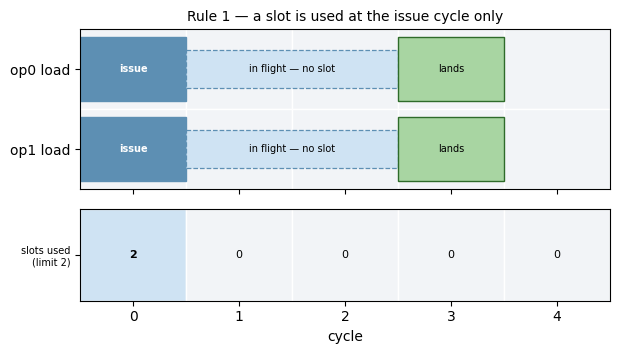

In [7]:
show_inflight(
    tiny_facts, packed_times, op_ids=[0, 1], span=len(packed_bundles),
    title="Rule 1 — a slot is used at the issue cycle only",
)

Both loads are handed over in cycle 0 and use both load slots. From cycle 1
onwards the strip along the bottom reads **zero slots used**, even though neither
load has produced anything yet. They are in flight, and being in flight costs no
slot at all.

A third and fourth load could therefore be issued at cycle 1 while the first two
are still travelling. What the limit forbids is *handing over* more than two in
the same cycle. It never forbids having four in the air at once.

In the kitchen picture: the limit is how many orders you may pass to the load
cook at a single tick. It is not how many dishes that cook may have on the go.

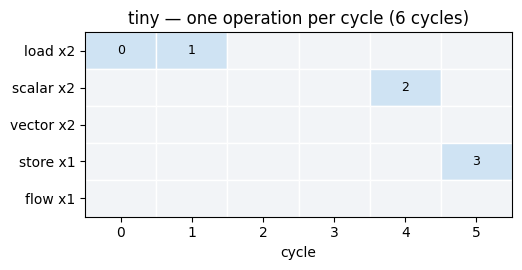

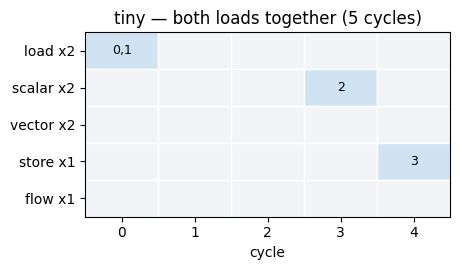

In [8]:
show_timeline(serial_tiny["bundles"], "tiny — one operation per cycle (6 cycles)")
show_timeline(packed_bundles, "tiny — both loads together (5 cycles)")

Each grid is the schedule. Rows are the five engines with their slot counts;
columns are cycles; a filled square holds the operation ids issued there. All
that changed between the two pictures is that one square moved left.

## 1.5 The scratchpad, and what allocation means

Now the second half. Where do the numbers live while the program runs?

On a laptop CPU there are registers, several levels of cache, and hardware that
moves data between them without being asked. **This machine has none of that.**
It has one flat array of 256 numbered words, called the **scratchpad**, and
that is the only storage an engine can read from or write to. It is not,
however, the only memory in the picture — §1.6 introduces the other kind, and
the difference between them decides what "correct" means.

In [9]:
print("scratchpad words           :", machine.SCRATCH_WORDS)
print("bits per word              : 32 (unsigned)")
print("words in a SIMD vector     :", machine.VLEN)
print("vector addresses must be divisible by", machine.VLEN)

scratchpad words           : 256
bits per word              : 32 (unsigned)
words in a SIMD vector     : 8
vector addresses must be divisible by 8


Think of it as 256 numbered lockers in a row, each holding one 32-bit number:

```
 word:   0     1     2     3     4     5    ...   255
       [   ] [   ] [   ] [   ] [   ] [   ]  ...  [   ]
```

Rules that follow from having nothing but lockers:

1. **Every produced value must be given a locker.** There is nowhere else to put
   it. That is what the `scratch` field of your answer is: a map from value name
   to locker number.
2. **A scalar takes one locker. A vector takes eight consecutive lockers**, and
   must start at a number divisible by eight (0, 8, 16, …). This is *alignment*.
3. **An engine can only read lockers, not other engines.** There is no
   forwarding of a result straight into the next operation; it goes to its
   locker first, which is what latency is counting down to.
4. **Two values may share a locker, but only if they are never both needed at
   the same time.**

Rule 4 is the interesting one, and it needs one more definition.

A value's **live interval** is the stretch of cycles during which its locker must
not be disturbed. It opens when the value is *written* (issue cycle + latency)
and closes at the *issue cycle of its last reader*, inclusive. Before it opens
the value does not exist yet; after it closes nobody will ever look at it again,
so the locker is free.

In [10]:
packed_life = direct_contract.lifetimes(tiny_facts, packed_times)
for name, (start, end) in packed_life.items():
    readers = tiny_facts.consumers[name]
    print(f"value {name!r}: written at cycle {start}, last read at cycle {end}  "
          f"(read by operations {list(readers) or 'nobody'})")

value 'a': written at cycle 3, last read at cycle 3  (read by operations [2])
value 'b': written at cycle 3, last read at cycle 3  (read by operations [2])
value 's': written at cycle 4, last read at cycle 4  (read by operations [3])


`a` and `b` both land at cycle 3 and are both read at cycle 3, so they overlap
and need two different lockers. `s` is written at cycle 4 — *after* `a` and `b`
were last read — so `s` may take over either of their lockers.

This is legal exactly because of the "writes happen before reads" rule: within a
cycle, all writes land first, then operands are read. So a new value may claim a
locker only if it writes **strictly after** the previous tenant's final read.

private lockers        -> 5 cycles, 3 words, accepted


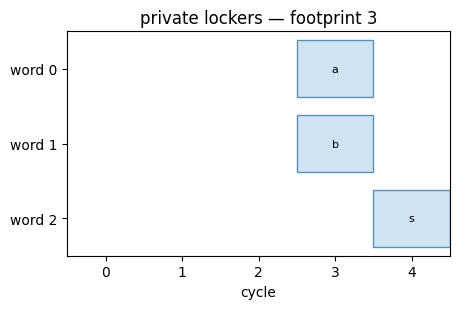

s reuses a's locker    -> 5 cycles, 2 words, accepted


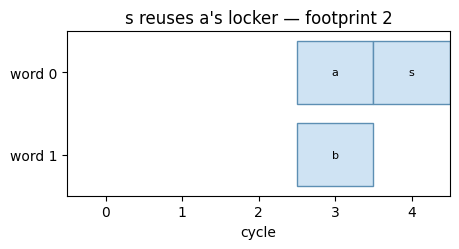

In [11]:
wasteful = {"a": 0, "b": 1, "s": 2}      # a private locker for every value
thrifty = {"a": 0, "b": 1, "s": 0}       # s moves into a's locker after a dies

for label, addresses in (("private lockers", wasteful), ("s reuses a's locker", thrifty)):
    candidate = {"scratch": addresses, "bundles": packed_bundles}
    cycles = machine.check_compilation(tiny, candidate)
    machine.check_case(tiny, candidate, tiny["cases"][0])
    words = machine.scratch_footprint(tiny, candidate)
    print(f"{label:22} -> {cycles} cycles, {words} words, accepted")
    show_lifetimes(tiny_facts, addresses, packed_life, cycles,
                   f"{label} — footprint {words}")

Same schedule, same answers, one fewer locker.

**Footprint** is the score's memory number: the *highest* locker end address
used, holes included. It is not a count of lockers. If you put a single vector
at address 8, the footprint is 16 even though lockers 0 to 7 are empty — which
is why alignment holes are worth avoiding.

In [12]:
print("one vector at address 0 -> footprint", 0 + machine.VLEN)
print("one vector at address 8 -> footprint", 8 + machine.VLEN, "(lockers 0-7 wasted)")

one vector at address 0 -> footprint 8
one vector at address 8 -> footprint 16 (lockers 0-7 wasted)


---

## 1.6 Buffers: the other memory, and the only one that is graded

The scratchpad is the machine's private workspace. It is created empty when your
schedule starts running and it is discarded when the schedule ends. **Nobody
ever inspects its final contents.**

What does get inspected is main memory, which is organised as named arrays
called **buffers**. Every program declares its own, as a single line mapping
each name to a length in words. Buffers hold the program's input when it starts
and its output when it finishes, and they are the only thing that survives.

Two kinds of memory, then, and it is worth keeping them apart:

| | **buffers** | **scratchpad** |
|---|---|---|
| what it is | named arrays in main memory | one flat array of 256 words |
| who declares it | the program | you, in the `scratch` map |
| reached by | `load` and `store` only | every operation's operands |
| at the end | **compared against the expected answer** | thrown away, never examined |

"Thrown away" does not mean ignored. The scratchpad is indispensable *while* the
program runs — every operand is read from it and every result written to it, and
allocating it badly makes the program compute nonsense. It is simply not part of
the **answer**. It is your rough paper; the buffers are the exam booklet.

In [13]:
case = tiny["cases"][0]

print("buffers the tiny program declares :", tiny["buffers"])
print("   (a mapping of buffer name -> length in words)")
print("their contents at the start       :", case)
print()

expected = machine.run_reference(tiny, case)       # the plain meaning of the program
compiled = {"scratch": thrifty, "bundles": packed_bundles}
actual = machine.run_compilation(tiny, compiled, case)   # what YOUR schedule produces

print("run_reference   returns:", expected)
print("run_compilation returns:", actual)
print("the grader's test is exactly `actual == expected` ->", actual == expected)
print()
print("both return buffers only; neither returns the scratchpad")

buffers the tiny program declares : {'x': 1, 'y': 1, 'out': 1}
   (a mapping of buffer name -> length in words)
their contents at the start       : {'x': [20], 'y': [22], 'out': [0]}

run_reference   returns: {'x': [20], 'y': [22], 'out': [42]}
run_compilation returns: {'x': [20], 'y': [22], 'out': [42]}
the grader's test is exactly `actual == expected` -> True

both return buffers only; neither returns the scratchpad


That is the whole of `check_case`, the function that decides whether a
compilation is correct. It runs the program twice — once straight down the list
of operations, ignoring scheduling entirely, and once through your bundles and
your scratch addresses — and compares the **buffers**. Both halves return main
memory and nothing else, which is why the scratchpad cannot enter the verdict.

The consequence is easy to test: if only the buffers are compared, then two
different scratch allocations of the same schedule must both be accepted.

In [14]:
for label, addresses in (("a private locker for each", wasteful),
                        ("s reuses a's locker", thrifty)):
    candidate = {"scratch": addresses, "bundles": packed_bundles}
    machine.check_case(tiny, candidate, case)      # raises if the answer is wrong
    words = machine.scratch_footprint(tiny, candidate)
    print(f"{label:26} {str(addresses):32} {words} words -> accepted")

print()
print("different scratch maps, identical buffers, both correct —")
print("which is the whole freedom the allocation half of the exercise gives you")

a private locker for each  {'a': 0, 'b': 1, 's': 2}         3 words -> accepted
s reuses a's locker        {'a': 0, 'b': 1, 's': 0}         2 words -> accepted

different scratch maps, identical buffers, both correct —
which is the whole freedom the allocation half of the exercise gives you


So the two halves of the score measure different things. Correctness is decided
by the buffers, and is absolute: no schedule that gets them wrong is worth
anything. The footprint is decided by the scratchpad, and is where the
*quality* of your answer lives.

This also explains the division between Rules 4 and 5, which §3 states exactly.
Rule 4 governs the scratchpad — getting it wrong corrupts a value in transit.
Rule 5 governs the buffers — getting it wrong changes the answer the grader
reads.

## 1.7 The answer your compiler returns

Putting both halves together, this is the entire output contract. Nothing else
is returned, and nothing else is examined.

In [15]:
answer = {"scratch": thrifty, "bundles": packed_bundles}
print(json.dumps(answer, indent=2, sort_keys=True))

{
  "bundles": [
    {
      "load": [
        0,
        1
      ]
    },
    {},
    {},
    {
      "scalar": [
        2
      ]
    },
    {
      "store": [
        3
      ]
    }
  ],
  "scratch": {
    "a": 0,
    "b": 1,
    "s": 0
  }
}


Read it as two sentences:

- **`scratch`** — "`a` lives in locker 0, `b` in locker 1, and `s` also in locker
  0 (after `a` is finished with it)."
- **`bundles`** — "at cycle 0 issue operations 0 and 1 on the load engine; cycles
  1 and 2 are stalls; at cycle 3 issue operation 2 on the scalar engine; at cycle
  4 issue operation 3 on the store engine."

The *position in the list* is the cycle number. That is why stalls are written
as empty dictionaries rather than omitted — an omitted cycle would renumber
everything after it.

Your whole task is to produce this dictionary for any program, as small as
possible in both senses, without ever producing an illegal one.

## 1.8 Why the two decisions cannot be taken separately

Here is the trap that makes this an interesting problem rather than two easy
ones.

Live intervals are defined in terms of *cycles*. Cycles are what scheduling
decides. So **the moment you change the schedule, every lifetime moves, and the
allocation problem you were solving becomes a different problem.** Pack
operations tightly and more values are alive at once, needing more lockers. Space
them out and you need fewer lockers but more cycles. The two halves of the score
pull against each other.

Section 6 demonstrates this with a measurement: delaying two loads by a single
cycle costs a cycle *and* a locker.

With those terms in hand — cycle, latency, engine, slot, bundle, issue,
scratchpad, locker, live interval, footprint — everything that follows is the
same machinery on a bigger program.

---

## 2. A real program

Programs are JSON. Here is a small real one from the exercise, in full.

In [16]:
PROGRAM_PATH = ROOT / ".reference/programs/02_scalar_dual_chain.json"
program = machine.load_program(PROGRAM_PATH)   # load_program also validates it

print(PROGRAM_PATH.read_text())

{
  "name": "scalar_dual_chain",
  "buffers": {"a": 1, "b": 1, "c": 1, "d": 1, "out": 2},
  "operations": [
    {"id": 0, "op": "load", "dest": "a0", "buffer": "a", "offset": 0},
    {"id": 1, "op": "load", "dest": "b0", "buffer": "b", "offset": 0},
    {"id": 2, "op": "load", "dest": "c0", "buffer": "c", "offset": 0},
    {"id": 3, "op": "load", "dest": "d0", "buffer": "d", "offset": 0},
    {"id": 4, "op": "mul", "dest": "left_product", "args": ["a0", "b0"]},
    {"id": 5, "op": "mul", "dest": "right_product", "args": ["c0", "d0"]},
    {"id": 6, "op": "add", "dest": "cross", "args": ["a0", "c0"]},
    {"id": 7, "op": "add", "dest": "left", "args": ["left_product", "cross"]},
    {"id": 8, "op": "xor", "dest": "right", "args": ["right_product", "cross"]},
    {"id": 9, "op": "store", "args": ["left"], "buffer": "out", "offset": 0},
    {"id": 10, "op": "store", "args": ["right"], "buffer": "out", "offset": 1}
  ],
  "cases": [
    {"a": [13], "b": [5], "c": [21], "d": [9], "out": [0,

Three parts, exactly as in the tiny example: `buffers` (main memory), the
`operations` themselves, and `cases` (input memory images the grader will run
your schedule on, comparing the final memory against a direct interpretation of
the operations).

"SSA" in the brief simply means **every value is written exactly once and never
reassigned**. That is why `dest` names are unique, and it is what makes "when is
this value alive?" a well-posed question at all.

Read this program as a dataflow graph:

```
 a  b   c  d          load a0, b0, c0, d0
  \ /    \ /
  mul    mul          left_product = a0*b0     right_product = c0*d0
    \     /
     \   /   a0 + c0 = cross
      \ /      |
      add     xor                              left = lp + cross   right = rp ^ cross
       |       |
     store   store                             out[0] = left       out[1] = right
```

Two independent chains sharing one value, `cross`. Nothing in the source order
says the four loads must happen one after another — that is the compiler's
choice, and it is exactly the choice being graded.

In [17]:
facts = direct_contract.derive(program)   # a read-only derived view of the program

print(f"{'id':>3}  {'op':7} {'engine':7} {'lat':>3}  {'dest':14} args")
for op in program["operations"]:
    spec = machine.OP_SPECS[op["op"]]
    print(f"{op['id']:>3}  {op['op']:7} {spec['engine']:7} {spec['latency']:>3}  "
          f"{str(op.get('dest', '-')):14} {op.get('args', [])}")

print("\nvalues that need a locker:", facts.value_names)
print("who reads each value      :", {k: v for k, v in facts.consumers.items()})

 id  op      engine  lat  dest           args
  0  load    load      3  a0             []
  1  load    load      3  b0             []
  2  load    load      3  c0             []
  3  load    load      3  d0             []
  4  mul     scalar    2  left_product   ['a0', 'b0']
  5  mul     scalar    2  right_product  ['c0', 'd0']
  6  add     scalar    1  cross          ['a0', 'c0']
  7  add     scalar    1  left           ['left_product', 'cross']
  8  xor     scalar    1  right          ['right_product', 'cross']
  9  store   store     1  -              ['left']
 10  store   store     1  -              ['right']

values that need a locker: ('a0', 'b0', 'c0', 'd0', 'left_product', 'right_product', 'cross', 'left', 'right')
who reads each value      : {'a0': (4, 6), 'b0': (4,), 'c0': (5, 6), 'd0': (5,), 'left_product': (7,), 'right_product': (8,), 'cross': (7, 8), 'left': (9,), 'right': (10,)}


---

## 3. The five rules, stated exactly

Everything here is read out of `machine.py`.

**Rule 1 — engine slots.** Each engine starts at most `ENGINE_LIMITS[engine]`
operations per cycle.

**Rule 2 — latency.** An operation issued in cycle `c` produces its result at
cycle `c + latency`, never sooner, and never in the same bundle.

**Rule 3 — the scratchpad.** 256 words. Scalars take one; vectors take eight
consecutive words starting at a multiple of eight.

**Rule 4 — sharing.** Two values may share words only if their live intervals do
not overlap; a new value must write strictly after the previous tenant's last
read.

**Rule 5 — memory ordering.** Loads may float past one another freely, but a
store must stay after every earlier overlapping access and before every later
one, and two ordered memory operations may not share a cycle. Provably disjoint
ranges may reorder. (Demonstrated in §9.)

The score's memory term is the **footprint**: highest end address used, holes
included.

Rules 1 to 3 are counting rules and are hard to get wrong. Rules 4 and 5 are
the two that quietly produce *wrong answers* rather than rejected schedules, so
both are worth seeing rather than reading.

### Rule 4 in a picture

Take the program just loaded and give it the simplest schedule there is — one
operation per cycle, the same `serial_compile` baseline used on the tiny program
in §1.3. That is enough to produce both cases of the rule.

value 'b0': written at cycle 4, last read at cycle 4
value 'c0': written at cycle 5, last read at cycle 7
value 'd0': written at cycle 6, last read at cycle 6


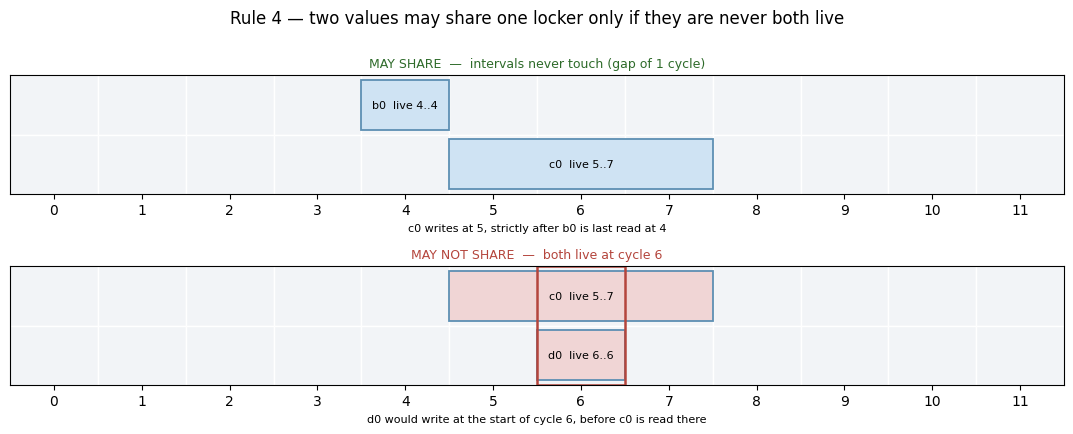

In [18]:
serial = machine.serial_compile(program)
serial_life = direct_contract.lifetimes(facts, issue_times(serial))

for name in ("b0", "c0", "d0"):
    start, end = serial_life[name]
    print(f"value {name!r}: written at cycle {start}, last read at cycle {end}")

show_sharing_rule(
    serial_life,
    pairs=[("b0", "c0"), ("c0", "d0")],
    span=len(serial["bundles"]),
    title="Rule 4 — two values may share one locker only if they are never both live",
)

Two pairs from the same schedule, and the difference between them is one cycle.

**`b0` and `c0` may share.** `b0` is written at cycle 4 and read at cycle 4, and
nothing wants it afterwards. `c0` is written at cycle 5. Five is strictly greater
than four, so `c0` may move straight into `b0`'s locker and the program still
computes the right answer.

**`c0` and `d0` may not.** `c0` is written at cycle 5 and is still needed at
cycle 7. `d0` wants to be written at cycle 6, in the middle of that. The red
outline marks cycle 6, where both would have to hold a number at once.

That second panel is why the rule says **strictly** after the last read, and not
"after or at the same time". Writes commit at the *start* of a cycle, before any
read happens — so a value written on a cycle where its predecessor is still
wanted destroys it before the reader ever arrives. The schedule looks perfectly
sensible and the answers come out wrong.

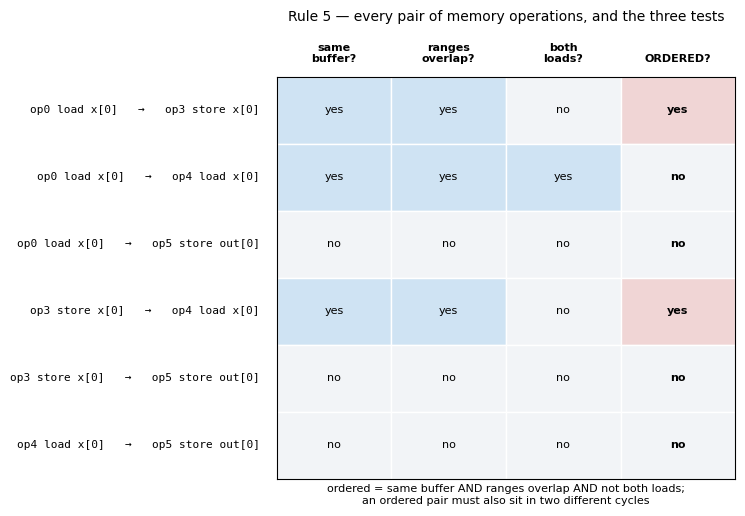

In [19]:
ordering_demo = {
    "name": "ordering_demo",
    "buffers": {"x": 1, "out": 1},
    "operations": [
        {"id": 0, "op": "load",  "dest": "v0", "buffer": "x", "offset": 0},
        {"id": 1, "op": "const", "dest": "one", "value": 1},
        {"id": 2, "op": "add",   "dest": "v1", "args": ["v0", "one"]},
        {"id": 3, "op": "store", "args": ["v1"], "buffer": "x", "offset": 0},
        {"id": 4, "op": "load",  "dest": "v2", "buffer": "x", "offset": 0},
        {"id": 5, "op": "store", "args": ["v2"], "buffer": "out", "offset": 0},
    ],
    "cases": [{"x": [7], "out": [0]}],
}
machine.validate_program(ordering_demo)

show_memory_ordering(
    ordering_demo,
    "Rule 5 — every pair of memory operations, and the three tests",
)

Read the second row carefully, because the exemption it shows is narrower than
it first appears. `op0` and `op4` touch the *same* word of the *same* buffer,
and the rule still reports no ordering between them, because **both are loads**.

That does **not** mean the two may be swapped in this program. `op0` reads 7 and
`op4` reads 8; swapping them would be nonsense. What the exemption means is that
this *pair* contributes no ordering requirement **of its own**. The ordering
between them still exists — it simply arrives by another route, which the next
figure shows.

Rows one and four are the constrained pairs: a store against an overlapping
load. Those must issue in that order, and — the half most easily missed — in
**two different cycles**, not merely in the right order within one. Everything
else in the table is free, either because the buffers differ or because the
ranges do not overlap.

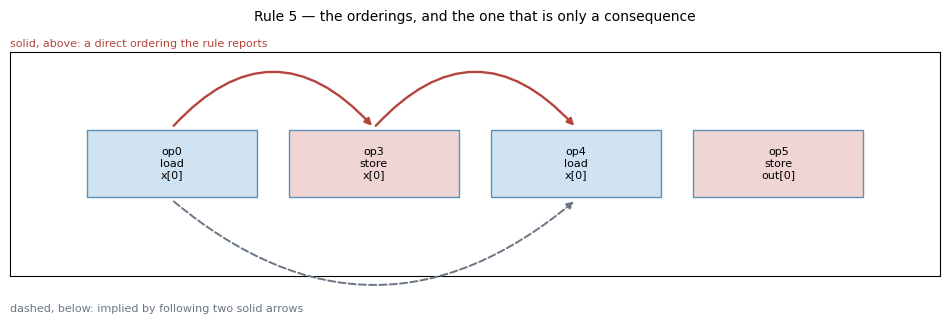

In [20]:
show_memory_chain(
    ordering_demo,
    "Rule 5 — the orderings, and the one that is only a consequence",
)

`op3` must follow `op0`, and `op4` must follow `op3`. Follow both and `op4` ends
up after `op0` anyway — the dashed arrow. The rule does not need to state that
edge, because the two solid ones already force it.

This is why the load-load exemption is safe rather than reckless. It removes an
edge that would have been *redundant* here. It genuinely frees two loads only
when no store sits between them: delete `op3` from this program and the two
loads could then issue in either order, or even together in one cycle.

§9 returns to this program and shows what the machine itself reports.

---

## 4. The starter compiler, and what it costs

The starter does the simplest correct thing: walk the operations in source
order, stall until each one's inputs are ready, put each in its own bundle, and
give every value a private locker.

starter: 12 cycles, 9 scratch words
scratch map: {'a0': 0, 'b0': 1, 'c0': 2, 'd0': 3, 'left_product': 4, 'right_product': 5, 'cross': 6, 'left': 7, 'right': 8}


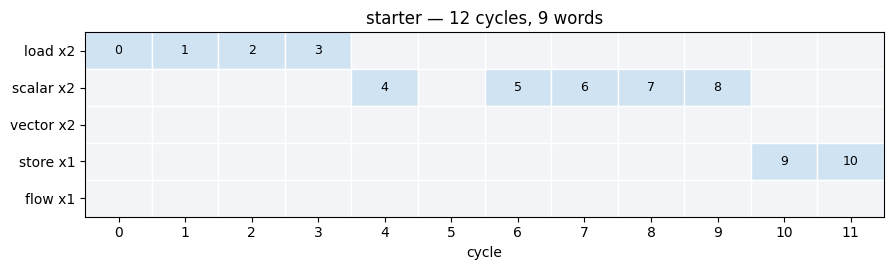

In [21]:
starter = compiler.compile_program(program)

starter_cycles = machine.check_compilation(program, starter)      # raises if illegal
for case in program["cases"]:
    machine.check_case(program, starter, case)                    # raises if wrong

starter_words = machine.scratch_footprint(program, starter)
print(f"starter: {starter_cycles} cycles, {starter_words} scratch words")
print("scratch map:", starter["scratch"])

show_timeline(starter["bundles"],
              f"starter — {starter_cycles} cycles, {starter_words} words")

Almost every slot is empty. Time is wasted because four independent loads take
four cycles on a two-slot engine; space is wasted because nine values hold nine
lockers although most are dead long before the end.

How much room is there, in principle? Two lower bounds are cheap to compute and
neither can be beaten by any legal schedule.

In [22]:
print("dependency lower bound (longest latency chain + 1):", facts.dependency_lower_bound())
print("engine lower bound (operations / slots per cycle) :", facts.engine_lower_bound())
print("=> no legal schedule of this program is shorter than:", facts.cycle_lower_bound(), "cycles")
print("   the starter takes:", starter_cycles)

dependency lower bound (longest latency chain + 1): 7
engine lower bound (operations / slots per cycle) : 3
=> no legal schedule of this program is shorter than: 7 cycles
   the starter takes: 12


---

## 5. Scheduling it by hand

Same method as the tiny program, one step at a time: fill both load slots, then
issue each operation as soon as its inputs have landed.

| cycle | reasoning |
|---:|---|
| 0 | loads 0 and 1 — the `load` engine has two slots, so use both |
| 1 | loads 2 and 3 |
| 3 | `a0`, `b0` landed at 0+3=3, so `mul` (id 4) may issue |
| 4 | `c0`, `d0` landed at 4: `mul` (5) and `add` (6) — two scalar slots, exactly the limit |
| 5 | `left_product` landed at 3+2=5 and `cross` at 4+1=5, so `add` (7) issues |
| 6 | `right_product` landed at 6 → `xor` (8); `left` landed at 6 → `store` (9) |
| 7 | `right` landed at 7 → `store` (10) |

A schedule is nothing more than this table: a map from operation id to issue
cycle.

In [23]:
times = {0: 0, 1: 0, 2: 1, 3: 1, 4: 3, 5: 4, 6: 4, 7: 5, 8: 6, 9: 6, 10: 7}

bundles = direct_contract.assemble_bundles(facts, times)
for cycle, bundle in enumerate(bundles):
    print(cycle, bundle if bundle else "(stall)")

0 {'load': [0, 1]}
1 {'load': [2, 3]}
2 (stall)
3 {'scalar': [4]}
4 {'scalar': [5, 6]}
5 {'scalar': [7]}
6 {'scalar': [8], 'store': [9]}
7 {'store': [10]}


---

## 6. Allocating it by hand

Compute each value's live interval from that schedule, using Rule 4.

In [24]:
life = direct_contract.lifetimes(facts, times)

print(f"{'value':15} {'written':>8} {'last read':>10}   interval")
for name in facts.value_names:
    start, end = life[name]
    bar = " " * start + "#" * (end - start + 1)
    print(f"{name:15} {start:>8} {end:>10}   |{bar:<10}|")

value            written  last read   interval
a0                     3          4   |   ##     |
b0                     3          3   |   #      |
c0                     4          4   |    #     |
d0                     4          4   |    #     |
left_product           5          5   |     #    |
right_product          6          6   |      #   |
cross                  5          6   |     ##   |
left                   6          6   |      #   |
right                  7          7   |       #  |


At cycle 4 three values are alive at once (`a0`, `c0`, `d0`); at cycle 6 three
again (`cross`, `right_product`, `left`). Nowhere four. So three lockers is a
genuine lower bound for *this* schedule — and it is achievable.

The policy below is the obvious one: walk the values in the order they are
written, and give each the lowest locker not held by something alive at the same
time.

In [25]:
def lowest_legal_addresses(facts, life):
    """Give each value, in write order, the lowest locker free while it is alive."""
    placed = {}
    for name in sorted(facts.value_names, key=lambda n: (life[n][0], n)):
        width = facts.width[name]
        start, end = life[name]
        address = 0
        while True:
            if width == machine.VLEN:                   # vectors must be 8-aligned
                address = machine.align_up(address, machine.VLEN)
            clash = any(
                base < address + width and address < base + facts.width[other]
                and start <= life[other][1] and life[other][0] <= end
                for other, base in placed.items()
            )
            if not clash:
                placed[name] = address
                break
            address += 1
    return placed


addresses = lowest_legal_addresses(facts, life)
hand = {"scratch": addresses, "bundles": bundles}

hand_cycles = machine.check_compilation(program, hand)
for case in program["cases"]:
    machine.check_case(program, hand, case)
hand_words = machine.scratch_footprint(program, hand)

print(f"hand-built: {hand_cycles} cycles, {hand_words} scratch words "
      f"(starter: {starter_cycles} / {starter_words})")
print()
for address in range(hand_words):
    tenants = [n for n, base in addresses.items() if base == address]
    print(f"  word {address}: " + ", ".join(
        f"{n} [{life[n][0]}..{life[n][1]}]" for n in sorted(tenants, key=lambda n: life[n])))

hand-built: 8 cycles, 3 scratch words (starter: 12 / 9)

  word 0: a0 [3..4], cross [5..6], right [7..7]
  word 1: b0 [3..3], c0 [4..4], left_product [5..5], left [6..6]
  word 2: d0 [4..4], right_product [6..6]


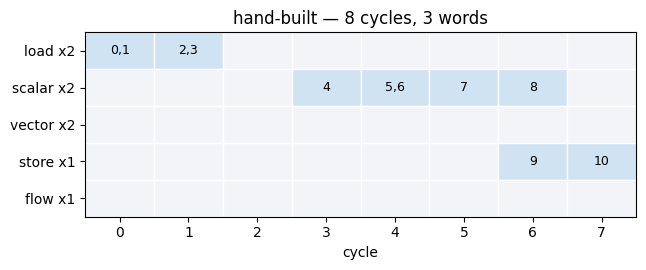

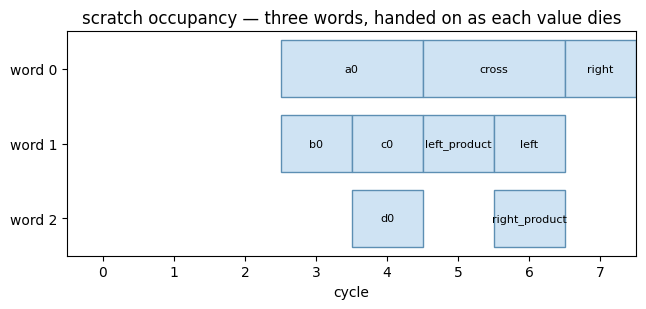

In [26]:
show_timeline(bundles, f"hand-built — {hand_cycles} cycles, {hand_words} words")
show_lifetimes(facts, addresses, life, hand_cycles,
               "scratch occupancy — three words, handed on as each value dies")

Nine values, three lockers. Each row is one locker passed from tenant to tenant
the moment the previous one has been read for the last time.

This hand-built answer — 8 cycles, 3 words — is exactly what our index-schema
compiler finds for this program. The interesting question is never "can a person
find it", it is "by what procedure does a compiler find it, and can that
procedure show the answer is legal".

### Turn the knob: the two decisions really are coupled

§1.8 claimed that changing the schedule changes the allocation problem. Measure
it. Delay the second pair of loads by exactly one cycle, leave the policy
untouched, and recompute both numbers.

original:          8 cycles, 3 words
loads delayed 1:   9 cycles, 4 words

lifetimes that moved:
  a0              (3, 4) -> (3, 5)
  c0              (4, 4) -> (5, 5)
  d0              (4, 4) -> (5, 5)
  left_product    (5, 5) -> (5, 6)
  right_product   (6, 6) -> (7, 7)
  cross           (5, 6) -> (6, 7)
  left            (6, 6) -> (7, 7)
  right           (7, 7) -> (8, 8)


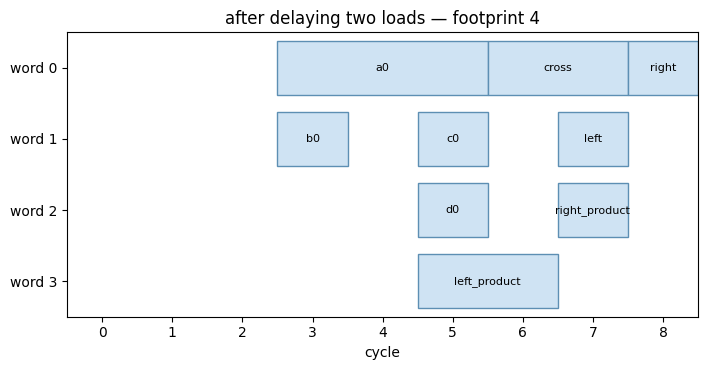

In [27]:
delayed = {0: 0, 1: 0, 2: 2, 3: 2, 4: 3, 5: 5, 6: 5, 7: 6, 8: 7, 9: 7, 10: 8}

delayed_life = direct_contract.lifetimes(facts, delayed)
delayed_compilation = {
    "scratch": lowest_legal_addresses(facts, delayed_life),
    "bundles": direct_contract.assemble_bundles(facts, delayed),
}
delayed_cycles = machine.check_compilation(program, delayed_compilation)
for case in program["cases"]:
    machine.check_case(program, delayed_compilation, case)
delayed_words = machine.scratch_footprint(program, delayed_compilation)

print(f"original:          {hand_cycles} cycles, {hand_words} words")
print(f"loads delayed 1:   {delayed_cycles} cycles, {delayed_words} words")
print("\nlifetimes that moved:")
for name in facts.value_names:
    if life[name] != delayed_life[name]:
        print(f"  {name:15} {life[name]} -> {delayed_life[name]}")

show_lifetimes(facts, delayed_compilation["scratch"], delayed_life, delayed_cycles,
               f"after delaying two loads — footprint {delayed_words}")

One cycle of delay, and the footprint grew too. The delay stretched `a0` and
`b0`'s intervals so that they are still alive when later values need lockers,
and the peak overlap rose from three to four. Neither number moved on its own.

---

## 7. Break it three ways

A rule you have not seen enforced is a rule you do not really know. Each case
below is illegal on purpose; the validator's own words are printed.

In [28]:
def expect_rejection(label, compilation):
    try:
        machine.check_compilation(program, compilation)
    except machine.CompileError as exc:
        print(f"{label:22} REJECTED -> {exc}")
    else:
        print(f"{label:22} accepted (this would be a bug in our understanding)")


# 1. latency: issue the multiply one cycle before its inputs have landed.
early = {**times, 4: 2}
expect_rejection("too early (latency)", {
    "scratch": lowest_legal_addresses(facts, direct_contract.lifetimes(facts, early)),
    "bundles": direct_contract.assemble_bundles(facts, early),
})

# 2. engine capacity: three scalar operations in a cycle with two scalar slots.
crowded = {**times, 4: 4}
expect_rejection("three in two slots", {
    "scratch": addresses,
    "bundles": direct_contract.assemble_bundles(facts, crowded),
})

# 3. allocation: make two values that are alive together share one locker.
aliased = dict(addresses)
aliased["left"] = aliased["cross"]          # cross is live [5..6], left is live [6..6]
expect_rejection("shared while alive", {"scratch": aliased, "bundles": bundles})

too early (latency)    REJECTED -> operation 4 uses 'a0' in cycle 2, but operation 0 produces it in cycle 3
three in two slots     REJECTED -> bundle 4 has 3 scalar operations, limit is 2
shared while alive     REJECTED -> scratch allocations 'left' and 'cross' overlap while live


The third is the subtle one, and the one most home-made allocators get wrong.
`cross` is read at cycle 6 and `left` is written at cycle 6, so they touch and
may not share a word. Had `left` been written at cycle 7, the same sharing would
have been perfectly legal. The difference is one cycle.

---

## 8. What "correct" actually means

Two separate gates. `check_compilation` looks only at the shape of your answer;
`check_case` actually runs it and compares the resulting memory against a direct
interpretation of the original operations.

In [29]:
case = program["cases"][0]
print("input memory    :", case)
print("reference result:", machine.run_reference(program, case))
print("our schedule    :", machine.run_compilation(program, hand, case))
print()
print("a0*b0 + (a0+c0) =", (13 * 5 + (13 + 21)) % 2**32,
      "   c0*d0 ^ (a0+c0) =", (21 * 9) ^ (13 + 21))

input memory    : {'a': [13], 'b': [5], 'c': [21], 'd': [9], 'out': [0, 0]}
reference result: {'a': [13], 'b': [5], 'c': [21], 'd': [9], 'out': [99, 159]}
our schedule    : {'a': [13], 'b': [5], 'c': [21], 'd': [9], 'out': [99, 159]}

a0*b0 + (a0+c0) = 99    c0*d0 ^ (a0+c0) = 159


In [30]:
# Swap where the two products live. Every value still has a locker, every locker
# is in range, and no operation moved.
swapped = dict(addresses)
swapped["left_product"], swapped["right_product"] = (
    swapped["right_product"], swapped["left_product"])

candidate = {"scratch": swapped, "bundles": bundles}
try:
    machine.check_compilation(program, candidate)
    print("structure  : accepted")
    machine.check_case(program, candidate, case)
    print("numbers    : accepted")
except machine.CompileError as exc:
    print("REJECTED ->", exc)

REJECTED -> scratch allocations 'left' and 'right_product' overlap while live


The structural gate caught it: the swap put a value on a locker another value
still occupies while both are alive. That is the usual outcome on this machine —
a compaction tight enough to be worth doing is almost always caught structurally
when it is wrong, because lockers are reusable exactly when lifetimes permit.

Do not read that as "the numeric check is redundant". The grader does not trust
your compiler's reasoning, only its output, and it re-derives the expected
memory from the original operations for every case, public and hidden. If your
compiler ever mis-modelled a latency or an ordering rule, this is the gate that
would say so.

---

## 9. Memory ordering

None of the eight public programs exercises this rule, which makes it easy to
miss and expensive to get wrong on the hidden set. The `ordering_demo` program
built in §3 — read a word, add one, write it back, then read it again — is the
smallest one that does, and §3 already showed which of its pairs are
constrained. Here is what the machine itself reports about them.

In [31]:
# ordering_demo was defined in section 3, with the picture of the rule.
for op in ordering_demo["operations"]:
    earlier = machine.memory_predecessors(ordering_demo, op["id"])
    if earlier:
        print(f"op {op['id']} ({op['op']} {op['buffer']}[{op['offset']}]) must issue "
              f"strictly after {earlier}")
print()
for path in sorted((ROOT / ".reference/programs").glob("*.json")):
    p = machine.load_program(path)
    ordered = sum(1 for op in p["operations"] if machine.memory_predecessors(p, op["id"]))
    print(f"{p['name']:20} operations with a memory predecessor: {ordered}")

op 3 (store x[0]) must issue strictly after [0]
op 4 (load x[0]) must issue strictly after [3]

scalar_pipeline      operations with a memory predecessor: 0
scalar_dual_chain    operations with a memory predecessor: 0
vector_axpy          operations with a memory predecessor: 0
vector_bitmix        operations with a memory predecessor: 0
mixed_broadcast      operations with a memory predecessor: 0
parallel_memory      operations with a memory predecessor: 0
scalar_selects       operations with a memory predecessor: 0
vector_reduction     operations with a memory predecessor: 0


The last column is zero everywhere: the public set never forces an ordering. The
brief says hidden programs use the same documented rules, so a compiler that
quietly ignores `memory_predecessors` can score well on all eight visible
programs and then produce wrong memory on a hidden one. Note the second half of
the rule too — ordered memory operations must be in **different** cycles, not
merely in the right order.

---

## 10. The score

The formula lives in `.reference/score.py`:

- per program, `speedup = baseline_cycles / your_cycles` and
  `reduction = baseline_words / your_words`, where the baseline is the frozen
  `machine.serial_compile`;
- take the **geometric** mean of each across programs;
- the combined score is `sqrt(cycle_geomean * scratch_geomean)`.

Geometric rather than arithmetic, because these are ratios: halving and doubling
should cancel, which an arithmetic mean would not do. The square root gives the
two objectives equal weight.

In [32]:
baseline = machine.serial_compile(program)
baseline_cycles = machine.check_compilation(program, baseline)
baseline_words = machine.scratch_footprint(program, baseline)

for label, cycles, words in (
    ("starter", starter_cycles, starter_words),
    ("hand-built", hand_cycles, hand_words),
    ("loads delayed", delayed_cycles, delayed_words),
):
    speedup = baseline_cycles / cycles
    reduction = baseline_words / words
    print(f"{label:14} {cycles:3d} cycles ({speedup:.3f}x)  {words:3d} words "
          f"({reduction:.3f}x)  combined {math.sqrt(speedup * reduction):.3f}x")

print(f"\nbaseline: {baseline_cycles} cycles, {baseline_words} words")

starter         12 cycles (1.000x)    9 words (1.000x)  combined 1.000x
hand-built       8 cycles (1.500x)    3 words (3.000x)  combined 2.121x
loads delayed    9 cycles (1.333x)    4 words (2.250x)  combined 1.732x

baseline: 12 cycles, 9 words


The starter scores exactly 1.000x by construction — it *is* the baseline. Two
things follow that are easy to miss:

1. **Scratch is the softer target.** Cycles are bounded below by the dependency
   chain, which you cannot shorten. Footprint is bounded only by peak overlap,
   and peak overlap is itself something scheduling can change.
2. **The public score is not the graded score.** Grading runs the same formula
   over sixteen programs — the eight you can see plus eight you cannot. Anything
   tuned to the visible eight is worth nothing on the other half.

---

## 11. Running the challenge yourself

Everything below runs from `luminal-challenge/.reference/`. The candidate task is
to rewrite `compile_program()` in `compiler.py`; `machine.py`, the programs and
the tests are off limits.

```sh
cd luminal-challenge/.reference

python3 -m unittest -v          # the public test suite
python3 score.py                # the public benchmark table

# compile one program and validate the result
python3 compiler.py programs/03_vector_axpy.json > /tmp/axpy.schedule.json
python3 machine.py programs/03_vector_axpy.json /tmp/axpy.schedule.json
```

The last command prints `OK: vector_axpy, cases=..., cycles=...` or `INVALID:`
with the reason. That pair — compile to stdout, validate — is the whole
development loop.

Rules from the brief worth keeping in front of you:

- Up to **four hours**, reading and testing included; submit what you have.
- The CLI must print **only** the schedule JSON on stdout; diagnostics go to
  stderr. The grader allows **20 seconds per program**.
- AI tools are allowed and must be **disclosed**, together with how you checked
  their output.
- Do **not** share the exercise or a solution publicly, and do not collaborate.
  (This is why the work in this repository stays local and unpushed.)

In [33]:
import subprocess

result = subprocess.run([sys.executable, "score.py"], cwd=ROOT / ".reference",
                        capture_output=True, text=True)
print(result.stdout or result.stderr)

Luminal Compiler Take Home — compiler engineering public benchmark
program                          cycles  baseline   speedup  scratch  reduction
------------------------------------------------------------
scalar_pipeline                      18        18    1.000x       15     1.000x
scalar_dual_chain                    12        12    1.000x        9     1.000x
vector_axpy                          14        14    1.000x       73     1.000x
vector_bitmix                        16        16    1.000x       89     1.000x
mixed_broadcast                      11        11    1.000x       42     1.000x
parallel_memory                      21        21    1.000x      128     1.000x
scalar_selects                       20        20    1.000x       16     1.000x
vector_reduction                     19        19    1.000x      137     1.000x
------------------------------------------------------------
public geometric-mean speedup: 1.000x
public geometric-mean scratch reduction: 1.000x
publi

---

## 12. Where to go next

You now have the whole contract: a fixed list of operations, a machine with
slots and latencies, 256 lockers of scratch, and a score that rewards shorter
schedules and smaller footprints without ever forgiving a wrong answer.

The standard way forward — and the one the brief itself suggests — is a greedy
list scheduler: keep a ready queue, prioritise operations on the critical path,
fill each bundle, then allocate by scanning live intervals.

The approach taken in this repository is different, and
[`01-index-method.ipynb`](01-index-method.ipynb) covers it: every scheduling and
allocation decision is expressed as a **query over Boolean index schemata**, so
that "is this placement legal?" is answered by intersecting sets of bit patterns
rather than by a heuristic rule. Its measured result on the eight public
programs is a combined **2.008x** against **1.901x** for a conventional greedy
baseline — better on three programs, equal on four, worse on one — at a median
compile time of **0.174 s against 0.00027 s**, which is **646 times slower**.
Both halves of that sentence matter.

That ratio is read from the accepted comparison of 72 runs rather than typed
here, and notebook 01 recomputes it in front of you. An earlier draft of this
paragraph said "roughly 1,500 times"; that figure was measured against the v3
compiler, before the optimization phase changed both arms.

Exercises before moving on:

1. In §5, move one operation later in `times` and re-run §6. Which lifetimes
   move? Does the footprint change? Can you make it *smaller* than three?
2. Schedule `01_scalar_pipeline.json` by hand with the same method and compare
   your score against the starter.
3. In §1.2, add a third `load` and try to issue all three in cycle 0. Predict the
   error message before you run it.